In [1]:
import numpy as np  
import pandas as pd  
import os 

In [2]:
import zipfile
import os

zip_path = "Brain Tumor detection.zip"
extract_path = "Brain Tumor detection"

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset Extracted Successfully!")

✅ Dataset Extracted Successfully!


In [3]:
root_path = '.\Brain Tumor detection\Training'

In [4]:
 
image_paths = [] 
labels = [] 

In [5]:
 
for label in os.listdir(root_path): 
    label_path = os.path.join(root_path, label) 
    if os.path.isdir(label_path): 
        for img_file in os.listdir(label_path): 
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg')): 
                image_paths.append(os.path.join(label_path, img_file)) 
                labels.append(label) 
 
df = pd.DataFrame({'image_path': image_paths, 'label': labels}) 
df

,image_path,label
0,.\Brain Tumor detection\Training\glioma_tumor\...,glioma_tumor
1,.\Brain Tumor detection\Training\glioma_tumor\...,glioma_tumor
2,.\Brain Tumor detection\Training\glioma_tumor\...,glioma_tumor
3,.\Brain Tumor detection\Training\glioma_tumor\...,glioma_tumor
4,.\Brain Tumor detection\Training\glioma_tumor\...,glioma_tumor
...,...,...
2865,.\Brain Tumor detection\Training\pituitary_tum...,pituitary_tumor
2866,.\Brain Tumor detection\Training\pituitary_tum...,pituitary_tumor
2867,.\Brain Tumor detection\Training\pituitary_tum...,pituitary_tumor
2868,.\Brain Tumor detection\Training\pituitary_tum...,pituitary_tumor


In [6]:
df.shape 

(2870, 2)

In [7]:
df.columns 


Index(['image_path', 'label'], dtype='object')

In [8]:
df.duplicated().sum() 

np.int64(0)

In [9]:
df.isnull().sum()

image_path    0
label         0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2870 entries, 0 to 2869
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  2870 non-null   object
 1   label       2870 non-null   object
dtypes: object(2)
memory usage: 45.0+ KB


In [11]:
df['label'].unique() 

array(['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor'],
      dtype=object)

In [12]:
df['label'].value_counts() 

label
pituitary_tumor     827
glioma_tumor        826
meningioma_tumor    822
no_tumor            395
Name: count, dtype: int64

In [13]:
import seaborn as sns 
import matplotlib.pyplot as plt 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6948\1318157085.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", palette="viridis", ax=ax)


<Axes: xlabel='label', ylabel='count'>

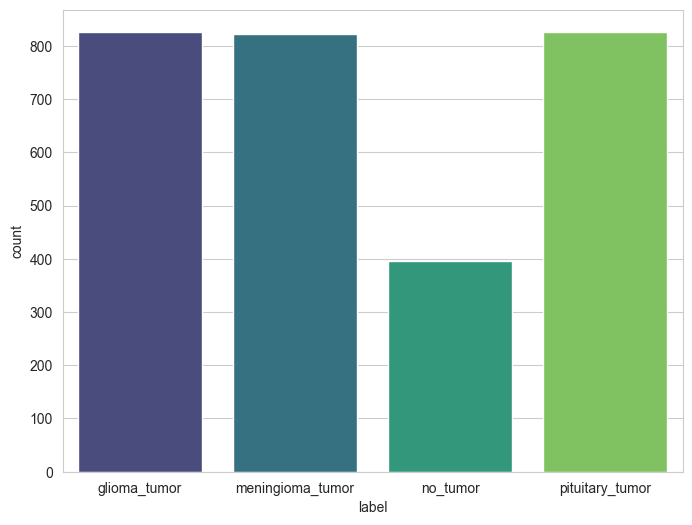

In [14]:
sns.set_style("whitegrid") 
 
fig, ax = plt.subplots(figsize=(8, 6)) 
sns.countplot(data=df, x="label", palette="viridis", ax=ax) 

In [15]:
ax.set_title("Distribution of Tumor Types", fontsize=14, fontweight='bold') 
ax.set_xlabel("Tumor Type", fontsize=12) 
ax.set_ylabel("Count", fontsize=12)

Text(24.000000000000007, 0.5, 'Count')

In [16]:
for p in ax.patches: 
    ax.annotate(f'{int(p.get_height())}',  
                (p.get_x() + p.get_width() / 2., p.get_height()),  
                ha='center', va='bottom', fontsize=11, color='black',  
                xytext=(0, 5), textcoords='offset points') 
 
plt.show()

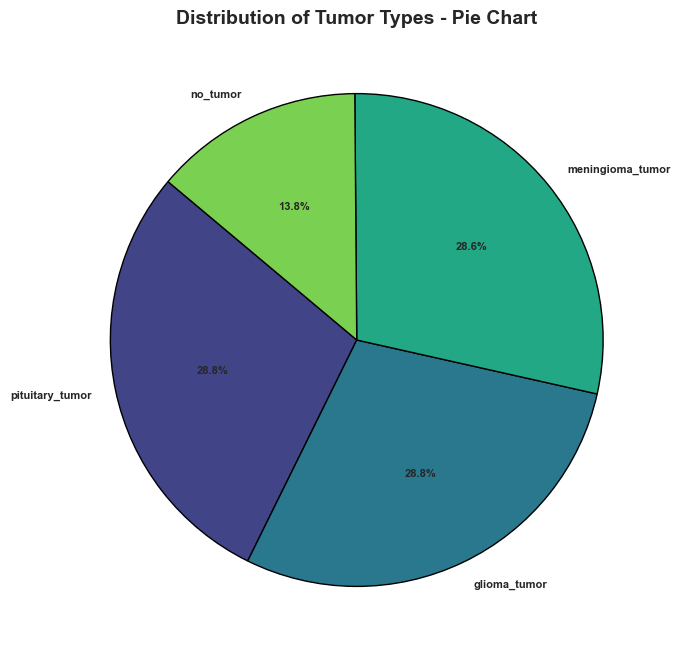

In [17]:
 
label_counts = df["label"].value_counts() 
 
fig, ax = plt.subplots(figsize=(10, 8)) 
colors = sns.color_palette("viridis", len(label_counts)) 
 
ax.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',  
       startangle=140, colors=colors, textprops={'fontsize': 8, 'weight': 
'bold'}, 
       wedgeprops={'edgecolor': 'black', 'linewidth': 1}) 
 
ax.set_title("Distribution of Tumor Types - Pie Chart", fontsize=14, 
fontweight='bold') 
 
plt.show()

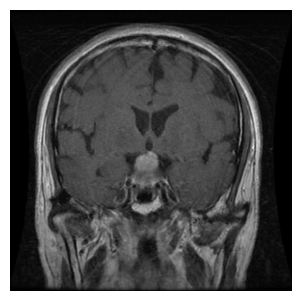

In [18]:
from PIL import Image 
num_images = 5 
unique_labels = df['label'].unique() 
plt.figure(figsize=(15, len(unique_labels) * 3)) 
for row_idx, label in enumerate(unique_labels): 
      label_images = df[df['label'] == 
 label].head(num_images)['image_path'].tolist() 
for col_idx, img_path in enumerate(label_images): 
   plt_idx = row_idx * num_images + col_idx + 1 
plt.subplot(len(unique_labels), num_images, plt_idx) 
img = Image.open(img_path).convert('L') 
plt.imshow(img, cmap='gray') 
plt.axis('off') 
if col_idx == 2:   
   plt.title(label, fontsize=10)
plt.tight_layout() 
plt.show() 

In [19]:
!pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable


In [20]:
import warnings 
warnings.filterwarnings('ignore') 
import torch 
import torch.nn as nn 
import torch.optim as optim 
from torch.utils.data import Dataset, DataLoader 
from torchvision import transforms, models 
from PIL import Image 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score 
from sklearn.model_selection import train_test_split 
from tqdm.auto import tqdm 
import warnings 
warnings.filterwarnings('ignore') 

In [21]:
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], 
random_state=42) 
 
max_samples = train_df['label'].value_counts().max() 
 
balanced_train_df = train_df.groupby('label', group_keys=False).apply( 
    lambda x: x.sample(n=max_samples, replace=True, random_state=42) 
).reset_index(drop=True) 
 
balanced_train_df = balanced_train_df[['image_path', 'label']] 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
 
label_list = sorted(df['label'].unique()) 
label_to_idx = {lbl: i for i, lbl in enumerate(label_list)} 
num_classes = len(label_list)

In [22]:
 
def calculate_theoretical_p(n, m, k): 
    return (1 - np.exp(-k * n / m)) ** k

In [23]:
 
class BrainTumorDataset(Dataset): 
    def __init__(self, dataframe, transform=None): 
        self.df = dataframe.reset_index(drop=True) 
        self.transform = transform 
    def __len__(self): return len(self.df) 
    def __getitem__(self, idx): 
        path = self.df.iloc[idx]['image_path'] 
        label = label_to_idx[self.df.iloc[idx]['label']] 
        img = Image.open(path).convert('RGB') 
        if self.transform: img = self.transform(img) 
        return img, label

In [24]:
class BloomAttention(nn.Module): 
    def __init__(self, embed_dim=768, num_heads=8):  
        super().__init__() 
        self.num_heads = num_heads 
        self.head_dim = embed_dim // num_heads  
        self.scale = self.head_dim ** -0.5 
         
        self.q_proj = nn.Linear(embed_dim, embed_dim) 
        self.k_proj = nn.Linear(embed_dim, embed_dim) 
        self.v_proj = nn.Linear(embed_dim, embed_dim) 
        self.out_proj = nn.Linear(embed_dim, embed_dim) 
         
        nn.init.normal_(self.q_proj.weight, std=0.02) 
        nn.init.normal_(self.k_proj.weight, std=0.02) 

In [25]:
def forward(self, x): 
        B, N, C = x.shape 
        q = self.q_proj(x).reshape(B, N, self.num_heads, self.head_dim).permute(0, 2, 1, 3) 
        k = self.k_proj(x).reshape(B, N, self.num_heads, self.head_dim).permute(0, 2, 1, 3) 
        v = self.v_proj(x).reshape(B, N, self.num_heads, self.head_dim).permute(0, 2, 1, 3) 
        attn_logits = (q @ k.transpose(-2, -1)) * self.scale 
        attn_weights = torch.softmax(attn_logits, dim=-1) 
         
        out = (attn_weights @ v).transpose(1, 2).reshape(B, N, C) 
        return self.out_proj(out) 

In [26]:
 
class BloomViT(nn.Module): 
    def __init__(self, num_classes): 
        super().__init__() 
        vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1) 
        self.patch_embed = vit.conv_proj 
        self.cls_token = vit.class_token 
        self.pos_embedding = vit.encoder.pos_embedding 
         
        self.blocks = nn.ModuleList() 
        for i in range(12): 
            if i < 2:  
                self.blocks.append(nn.ModuleDict({ 
                    'norm1': nn.LayerNorm(768), 
                    'attn': BloomAttention(768, 8), 
                    'norm2': nn.LayerNorm(768), 
                    'mlp': vit.encoder.layers[i].mlp 
                })) 
            else:  
                self.blocks.append(vit.encoder.layers[i]) 
         
        self.norm = nn.LayerNorm(768) 
        self.head = nn.Linear(768, num_classes) 

In [31]:
 def forward(self, x): 
        B = x.shape[0] 
        x = self.patch_embed(x).flatten(2).transpose(1, 2) 
        cls_token = self.cls_token.expand(B, -1, -1) 
        x = torch.cat((cls_token, x), dim=1) 
        x = x + self.pos_embedding 
         
        for blk in self.blocks: 
            if isinstance(blk, nn.ModuleDict): 
                x = x + blk['attn'](blk['norm1'](x)) 
                x = x + blk['mlp'](blk['norm2'](x)) 
            else: 
                x = blk(x) 
        return self.head(self.norm(x[:, 0])) 

In [41]:
class BloomViT(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # layers here

    def forward(self, x):  
        # operations here
        return x

In [42]:
print(list(model.parameters()))

[]


In [54]:
train_transform = transforms.Compose([ 
    transforms.Resize((224, 224)), 
    transforms.RandomHorizontalFlip(), 
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
]) 
 
train_loader = DataLoader(BrainTumorDataset(balanced_train_df, train_transform), batch_size=24, shuffle=True) 
val_loader = DataLoader(BrainTumorDataset(val_df, train_transform), batch_size=24, shuffle=False)  
model = BloomViT(num_classes).to(device)  
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01) 
criterion = nn.CrossEntropyLoss() 
 
for epoch in range(5): 
    model.train() 
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}") 
    for imgs, labels in pbar: 
        imgs, labels = imgs.to(device), labels.to(device) 
        optimizer.zero_grad() 
        loss = criterion(model(imgs), labels) 
        loss.backward() 
        optimizer.step() 
        pbar.set_postfix(loss=f"{loss.item():.4f}") 
 
model.eval() 
y_true, y_pred = [], [] 
with torch.no_grad(): 
    for imgs, labels in tqdm(val_loader): 
        outputs = model(imgs.to(device)) 
        y_pred.extend(outputs.argmax(dim=1).cpu().numpy()) 
        y_true.extend(labels.numpy()) 
 
print(classification_report(y_true, y_pred, target_names=label_list)) 
 
n, m, k = 196, 96, 8 
print(f"Improved Bloom False Positive Probability (p): {calculate_theoretical_p(n, m, k):.4f}") 


Epoch 1:   0%|                                                                                 | 0/111 [00:00<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (16128x224 and 768x4)